# Pandas & Plotly Visualization

In [6]:
import pandas as pd
import numpy as np 
import plotly.express as px 
import plotly.graph_objects as go 
import plotly.io as pio 
import seaborn as sns 
import warnings 

titanic = pd.read_csv("s3://bauntek-bootcamp-shared/titanic.csv")
tips = pd.read_csv("s3://bauntek-bootcamp-shared/tips.csv")

In [7]:
titanic.shape

(891, 16)

In [8]:
titanic.head(5)

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    object 
 9   class        891 non-null    object 
 10  who          891 non-null    object 
 11  adult_male   891 non-null    bool   
 12  deck         203 non-null    object 
 13  embark_town  889 non-null    object 
 14  alive        891 non-null    object 
 15  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(7)
memory usage: 99.3+ KB


In [11]:
titanic.describe().round(2)

,Unnamed: 0,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,445.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,222.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,445.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,667.50,1.00,3.00,38.00,1.00,0.00,31.00
max,890.00,1.00,3.00,80.00,8.00,6.00,512.33


In [14]:
for col in ["survived", "pclass", "sex", "embarked"]:
    print(col, sorted(titanic[col].dropna().unique()))

survived [0, 1]
pclass [1, 2, 3]
sex ['female', 'male']
embarked ['C', 'Q', 'S']


In [19]:
surv = (titanic["survived"]
       .map({0:"Did not survive", 1: "Survived"})
        .value_counts()
        .reset_index()
       )
surv

,survived,count
0,Did not survive,549
1,Survived,342


In [20]:
titanic

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [22]:
%%duckdb -t df -o survived_counts
SELECT COUNT(survived) FROM titanic GROUP BY survived

,count(survived)
0,549
1,342


In [23]:
survived_counts

,count(survived)
0,549
1,342


In [24]:
surv

,survived,count
0,Did not survive,549
1,Survived,342


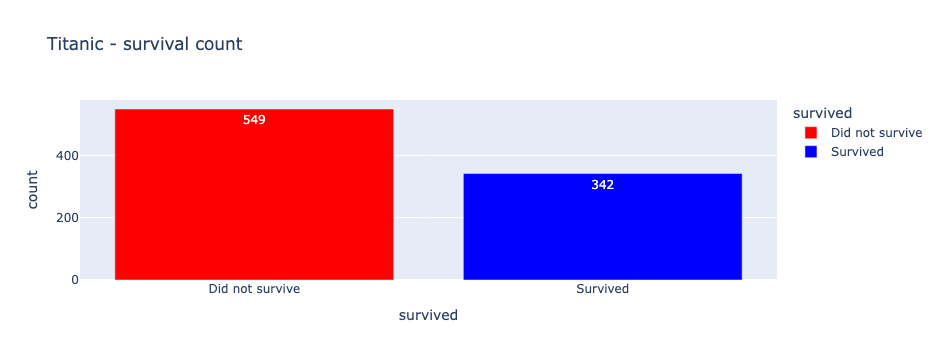

In [26]:
px.bar(surv,
       x = "survived", y="count",
       color = "survived",
        color_discrete_map = {"Did not survive":"red", "Survived":"blue"},
        text = "count",
        title = "Titanic - survival count"
      )

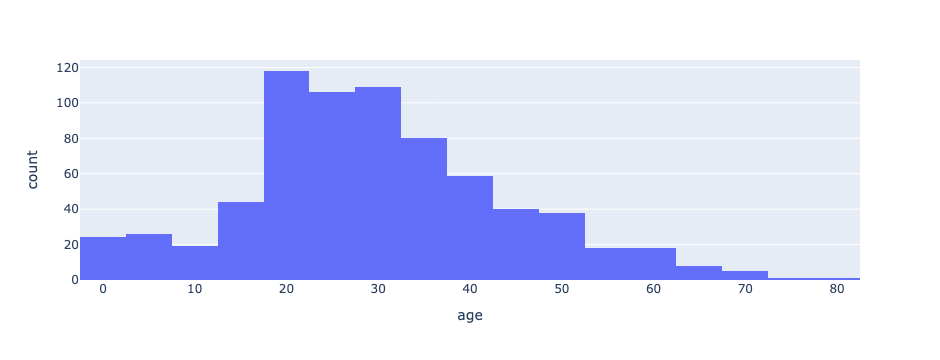

In [27]:
px.histogram(
    titanic,
    x = "age",
    nbins = 30
)

In [30]:
tips = pd.read_csv("s3://bauntek-bootcamp-shared/tips.csv")
tips

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...,...
239,239,29.03,5.92,Male,No,Sat,Dinner,3
240,240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,242,17.82,1.75,Male,No,Sat,Dinner,2


### 🏋️ Exercise - First Look + First Chart (Tips)

Using the `tips` dataset:

1. Print `shape`, `.dtypes`, and `value_counts()` for `day` and `time`.
2. Draw a `px.bar` showing the **count of bills per day** (`['Thur','Fri','Sat','Sun']`).  
   Use `color='day'` and add `text_auto=True` for value labels.

In [31]:
tips.shape

(244, 8)

In [32]:
tips.dtypes 

Unnamed: 0      int64
total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

In [33]:
tips["day"].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [34]:
tips["time"].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [38]:
day_counts = (tips["day"]
             .value_counts()
              .reset_index()
             )

day_counts

,day,count
0,Sat,87
1,Sun,76
2,Thur,62
3,Fri,19


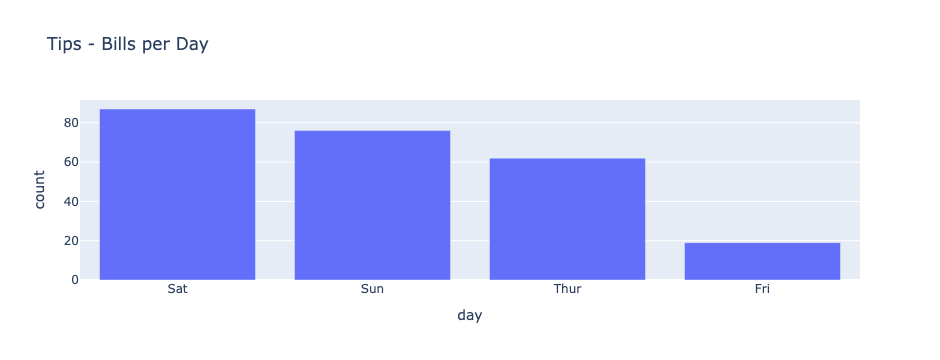

In [39]:
px.bar(day_counts, x="day",y="count", title="Tips - Bills per Day")